# 🦌 WildEye — Setup + Baseline Pipeline Validation

## 1. Mount Google Drive & Enter Project Folder


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/deeplearn/hack1')
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# Create subfolders we'll use throughout the project
for sub in ['data/raw', 'models', 'results/figures']:
    (PROJECT_ROOT / sub).mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)
print(f'Working directory: {os.getcwd()}')
!ls -la

Working directory: /content/drive/MyDrive/deeplearn/hack1
total 599755
-rw------- 1 root root     27434 May 22 12:14 01_baseline_pipeline.ipynb
-rw------- 1 root root 614087302 Dec 12  2019 animals10.zip
drwx------ 3 root root      4096 May 22 11:59 data
drwx------ 2 root root      4096 May 22 11:59 models
-rw------- 1 root root     20095 May 22 11:58 no01_baseline_training.ipynb
drwx------ 3 root root      4096 May 22 11:59 results
-rw------- 1 root root       376 May 22 11:27 Untitled0.ipynb


## 2. Install Dependencies & Check GPU

In [3]:
!pip install -q albumentations scikit-learn matplotlib seaborn tqdm pillow

In [4]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU detected. Runtime → Change runtime type → T4 GPU → Save')

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 3. Get the Dataset



In [5]:
# Check if data already exists. If yes, skip downloads.
data_already_there = any((PROJECT_ROOT / 'data/raw').iterdir())
print('Data already downloaded' if data_already_there else 'Data folder empty — run Path A or Path B below')

Data already downloaded


### Kaggle Animals-10

`

In [6]:
import os, json

# ↓↓↓ 把 Kaggle 显示给你的值填在这里 ↓↓↓
KAGGLE_USERNAME = "kemingzhou666"   # 例如 "john_doe"
KAGGLE_KEY      = "KGAT_e89bf51a7640611dd086fec57401f518"        # 例如 "abc123def456..."
# ↑↑↑ 填完之后运行这个 cell ↑↑↑

kaggle_json = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_path = os.path.expanduser("~/.kaggle/kaggle.json")
with open(kaggle_path, "w") as f:
    json.dump(kaggle_json, f)
os.chmod(kaggle_path, 0o600)

!pip install -q kaggle
print("✓ kaggle.json created and ready")

✓ kaggle.json created and ready


In [ ]:

!unzip -q -o animals10.zip -d data/raw
!rm animals10.zip
!ls data/raw/

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:24<00:00, 25.6MB/s]

raw-img  translate.py


In [ ]:
from pathlib import Path

translate = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider',
    'scoiattolo': 'squirrel',
}

# The unzipped folder is data/raw/raw-img/<italian_class>/
img_root = PROJECT_ROOT / 'data/raw/raw-img'
if img_root.exists():
    for it, en in translate.items():
        src, dst = img_root / it, img_root / en
        if src.exists() and not dst.exists():
            src.rename(dst)
            print(f'{it} → {en}')
    print('\nClasses:', sorted([p.name for p in img_root.iterdir() if p.is_dir()]))
    DATA_DIR = img_root
else:
    print('raw-img folder not found. Did Path A.3 run successfully?')

cane → dog
cavallo → horse
elefante → elephant
farfalla → butterfly
gallina → chicken
gatto → cat
mucca → cow
pecora → sheep
ragno → spider
scoiattolo → squirrel

Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


## 4. Configuration



In [ ]:
import json, random
import numpy as np

try:
    DATA_DIR
except NameError:
    DATA_DIR = PROJECT_ROOT / 'data/raw/raw-img'  # Animals-10 default location

FAST_DEBUG = False   # ← Set to False once the pipeline is verified end-to-end

CFG = {
    'data_dir': str(DATA_DIR),
    'image_size': 224,
    'batch_size': 32,
    'num_workers': 2,
    'val_split': 0.15,
    'test_split': 0.15,

    'num_classes': None,            # auto-filled
    'epochs': 3 if FAST_DEBUG else 10,
    'samples_per_class': 200 if FAST_DEBUG else None,   # None = use all
    'lr_head': 1e-3,
    'weight_decay': 1e-4,
    'freeze_backbone': True,

    'output_dir': str(PROJECT_ROOT / 'models'),
    'figures_dir': str(PROJECT_ROOT / 'results/figures'),
    'run_name': 'baseline_no_aug' + ('_debug' if FAST_DEBUG else ''),
}

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(json.dumps(CFG, indent=2))

{
  "data_dir": "/content/drive/MyDrive/deeplearn/hack1/data/raw/raw-img",
  "image_size": 224,
  "batch_size": 32,
  "num_workers": 2,
  "val_split": 0.15,
  "test_split": 0.15,
  "num_classes": null,
  "epochs": 10,
  "samples_per_class": null,
  "lr_head": 0.001,
  "weight_decay": 0.0001,
  "freeze_backbone": true,
  "output_dir": "/content/drive/MyDrive/deeplearn/hack1/models",
  "figures_dir": "/content/drive/MyDrive/deeplearn/hack1/results/figures",
  "run_name": "baseline_no_aug"
}


## 5. Dataset & Splits

In [26]:
from collections import Counter, defaultdict
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


class CameraTrapDataset(Dataset):
    """Generic image-folder dataset. Returns (image_tensor, label_idx).

    Custom class (not torchvision.ImageFolder) so the next notebook
    can plug in albumentations transforms without changes elsewhere.
    """
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.idx_to_class = {v: k for k, v in class_to_idx.items()}
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def scan_folder(root):
    root = Path(root)
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    samples = []
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for cls in classes:
        for p in (root / cls).rglob('*'):
            if p.suffix.lower() in exts:
                samples.append((str(p), class_to_idx[cls]))
    return samples, class_to_idx


all_samples, class_to_idx = scan_folder(CFG['data_dir'])
idx_to_class = {v: k for k, v in class_to_idx.items()}
CFG['num_classes'] = len(class_to_idx)

print(f'Found {len(all_samples)} images across {CFG["num_classes"]} classes')
for idx, count in sorted(Counter([s[1] for s in all_samples]).items()):
    print(f'  {idx_to_class[idx]:20s}: {count}')

Found 26179 images across 10 classes
  butterfly           : 2112
  cat                 : 1668
  chicken             : 3098
  cow                 : 1866
  dog                 : 4863
  elephant            : 1446
  horse               : 2623
  sheep               : 1820
  spider              : 4821
  squirrel            : 1862


In [27]:
# --- FAST_DEBUG: subsample to N per class ---
if CFG['samples_per_class'] is not None:
    per_class = defaultdict(list)
    for s in all_samples:
        per_class[s[1]].append(s)
    capped = []
    for lbl, items in per_class.items():
        random.shuffle(items)
        capped.extend(items[:CFG['samples_per_class']])
    all_samples = capped
    print(f'FAST_DEBUG: reduced to {len(all_samples)} samples '
          f'({CFG["samples_per_class"]} per class)')

# --- Stratified train/val/test split ---
paths  = [s[0] for s in all_samples]
labels = [s[1] for s in all_samples]

train_p, temp_p, train_l, temp_l = train_test_split(
    paths, labels,
    test_size=CFG['val_split'] + CFG['test_split'],
    stratify=labels, random_state=SEED,
)
val_ratio = CFG['val_split'] / (CFG['val_split'] + CFG['test_split'])
val_p, test_p, val_l, test_l = train_test_split(
    temp_p, temp_l, test_size=1 - val_ratio,
    stratify=temp_l, random_state=SEED,
)

train_samples = list(zip(train_p, train_l))
val_samples   = list(zip(val_p, val_l))
test_samples  = list(zip(test_p, test_l))
print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

Train: 18325 | Val: 3927 | Test: 3927


## 6. Transforms — Baseline (no augmentation)



Batch: torch.Size([32, 3, 224, 224]), labels: torch.Size([32])


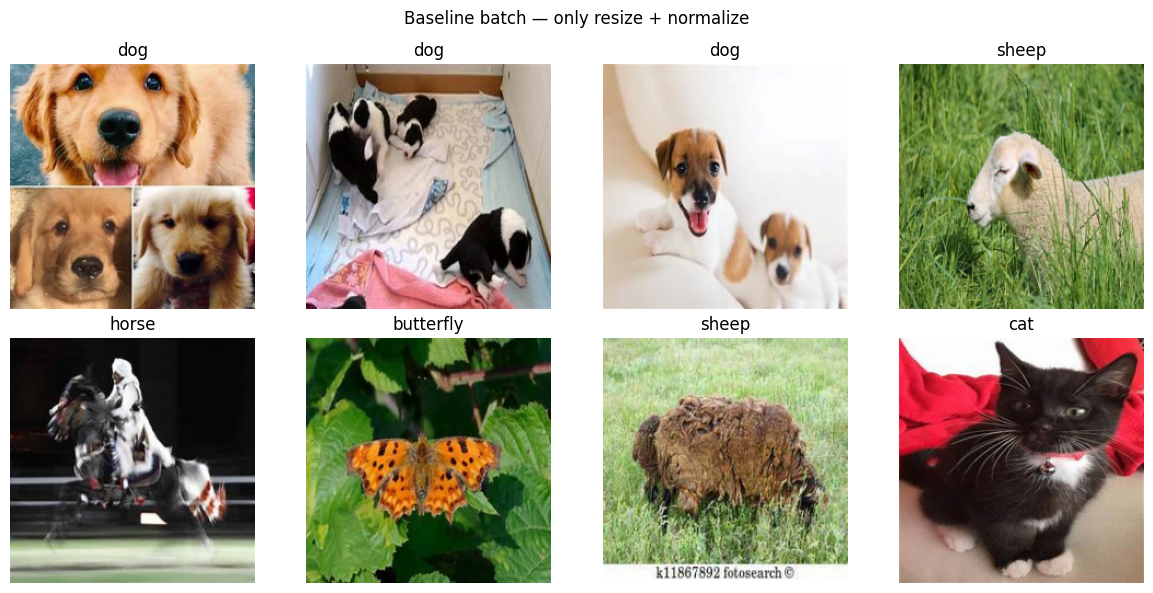

In [28]:
from torchvision import transforms
import matplotlib.pyplot as plt

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

baseline_train_tf = transforms.Compose([
    transforms.Resize((CFG['image_size'], CFG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((CFG['image_size'], CFG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = CameraTrapDataset(train_samples, class_to_idx, transform=baseline_train_tf)
val_ds   = CameraTrapDataset(val_samples,   class_to_idx, transform=eval_tf)
test_ds  = CameraTrapDataset(test_samples,  class_to_idx, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

# Sanity-check a batch
imgs, lbls = next(iter(train_loader))
print(f'Batch: {imgs.shape}, labels: {lbls.shape}')

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.flat, imgs[:8], lbls[:8]):
    img_np = img.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    ax.imshow(np.clip(img_np, 0, 1))
    ax.set_title(idx_to_class[lbl.item()])
    ax.axis('off')
plt.suptitle('Baseline batch — only resize + normalize')
plt.tight_layout()
plt.show()

## 7. Model — Transfer Learning with EfficientNet-B0



In [29]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

def build_model(num_classes, freeze_backbone=True):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

model = build_model(CFG['num_classes'], CFG['freeze_backbone']).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

Trainable params: 12,810 / 4,020,358 (0.32%)


## 8. Training

In [30]:
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=CFG['lr_head'], weight_decay=CFG['weight_decay'],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    tot_loss, tot_correct, tot_n = 0.0, 0, 0
    pbar = tqdm(loader, desc='train' if is_train else 'eval', leave=False)
    with torch.set_grad_enabled(is_train):
        for imgs, lbls in pbar:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, lbls)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            tot_loss    += loss.item() * imgs.size(0)
            tot_correct += (logits.argmax(1) == lbls).sum().item()
            tot_n       += imgs.size(0)
            pbar.set_postfix(loss=tot_loss / tot_n, acc=tot_correct / tot_n)
    return tot_loss / tot_n, tot_correct / tot_n

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_path = Path(CFG['output_dir']) / f"{CFG['run_name']}_best.pth"

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader)
    scheduler.step()
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:02d}/{CFG["epochs"]} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {vl_loss:.4f} acc {vl_acc:.4f}')
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_to_idx': class_to_idx,
            'config': CFG,
            'epoch': epoch,
            'val_acc': vl_acc,
        }, best_path)
        print(f'  ✓ saved best to {best_path.name}')

print(f'\nBest val acc: {best_val_acc:.4f}')

train:   0%|          | 0/573 [00:00<?, ?it/s]

eval:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.4993 acc 0.8764 | val loss 0.2096 acc 0.9447
  ✓ saved best to baseline_no_aug_best.pth


train:   0%|          | 0/573 [00:00<?, ?it/s]

eval:   0%|          | 0/123 [00:00<?, ?it/s]

...

eval:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 09/10 | train loss 0.1884 acc 0.9410 | val loss 0.1489 acc 0.9582
  ✓ saved best to baseline_no_aug_best.pth


train:   0%|          | 0/573 [00:00<?, ?it/s]

eval:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.1937 acc 0.9394 | val loss 0.1510 acc 0.9539

Best val acc: 0.9582


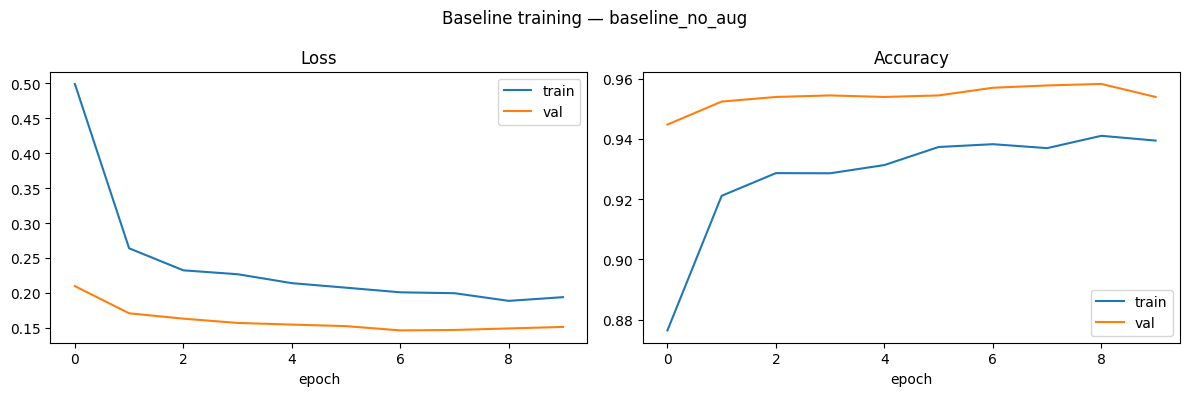

Saved → /content/drive/MyDrive/deeplearn/hack1/results/figures/baseline_no_aug_curves.png


In [31]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.suptitle(f'Baseline training — {CFG["run_name"]}')
plt.tight_layout()
curves_path = Path(CFG['figures_dir']) / f"{CFG['run_name']}_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print(f'Saved → {curves_path}')

## 9. Evaluation on Clean Test Set



In [32]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='test'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.numpy().tolist())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro')
print(f'Clean test accuracy: {test_acc:.4f}')
print(f'Clean test macro-F1: {test_f1:.4f}\n')

target_names = [idx_to_class[i] for i in range(CFG['num_classes'])]
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))

test:   0%|          | 0/123 [00:00<?, ?it/s]

Clean test accuracy: 0.9600
Clean test macro-F1: 0.9570

              precision    recall  f1-score   support

   butterfly      0.978     0.968     0.973       317
         cat      0.963     0.924     0.943       250
     chicken      0.980     0.968     0.974       465
         cow      0.931     0.911     0.921       280
         dog      0.945     0.963     0.954       729
    elephant      0.972     0.963     0.968       217
       horse      0.929     0.959     0.944       394
       sheep      0.942     0.945     0.943       273
      spider      0.983     0.982     0.983       723
    squirrel      0.968     0.968     0.968       279

    accuracy                          0.960      3927
   macro avg      0.959     0.955     0.957      3927
weighted avg      0.960     0.960     0.960      3927



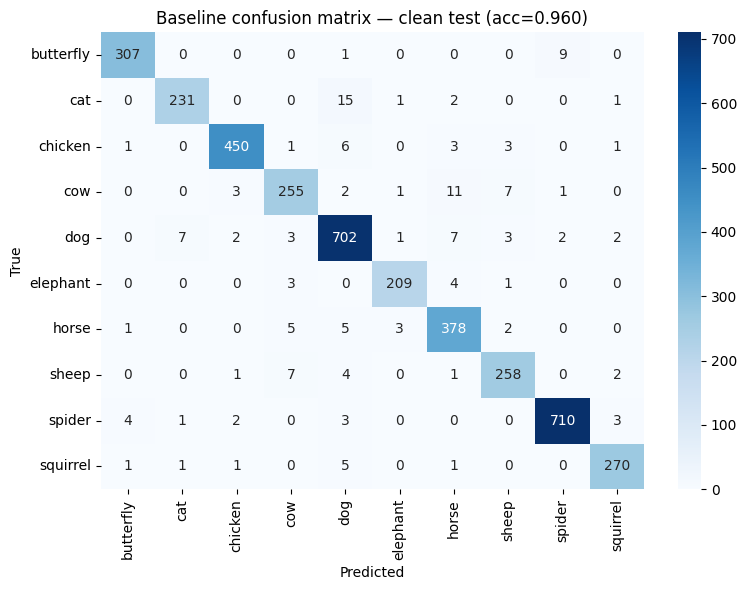

Saved → /content/drive/MyDrive/deeplearn/hack1/results/figures/baseline_no_aug_cm_clean.png


In [33]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Baseline confusion matrix — clean test (acc={test_acc:.3f})')
plt.tight_layout()
cm_path = Path(CFG['figures_dir']) / f"{CFG['run_name']}_cm_clean.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'Saved → {cm_path}')

## 10. Save Metrics for Cross-Experiment Comparison



In [34]:
metrics = {
    'run_name': CFG['run_name'],
    'config': CFG,
    'best_val_acc': best_val_acc,
    'clean_test_acc': test_acc,
    'clean_test_f1_macro': test_f1,
    'history': history,
    'class_to_idx': class_to_idx,
}
metrics_path = Path(CFG['output_dir']) / f"{CFG['run_name']}_metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved → {metrics_path}')
print('\nAll outputs:')
!ls -la {CFG['output_dir']} {CFG['figures_dir']}

Metrics saved → /content/drive/MyDrive/deeplearn/hack1/models/baseline_no_aug_metrics.json

All outputs:
/content/drive/MyDrive/deeplearn/hack1/models:
total 31980
-rw------- 1 root root 16385477 May 22 13:07 baseline_no_aug_best.pth
-rw------- 1 root root 16357081 May 22 12:23 baseline_no_aug_debug_best.pth
-rw------- 1 root root     1209 May 22 12:26 baseline_no_aug_debug_metrics.json
-rw------- 1 root root     2055 May 22 13:12 baseline_no_aug_metrics.json

/content/drive/MyDrive/deeplearn/hack1/results/figures:
total 273
-rw------- 1 root root 88340 May 22 13:12 baseline_no_aug_cm_clean.png
-rw------- 1 root root 66726 May 22 13:11 baseline_no_aug_curves.png
-rw------- 1 root root 45279 May 22 12:26 baseline_no_aug_debug_cm_clean.png
-rw------- 1 root root 77475 May 22 12:25 baseline_no_aug_debug_curves.png


In [35]:
# 在 Colab 新 cell 里运行
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/deeplearn/hack1/data/raw/raw-img')
for d in sorted(data_dir.iterdir()):
    if d.is_dir():
        n_imgs = len(list(d.rglob('*.jpg'))) + len(list(d.rglob('*.jpeg')))
        print(f'{d.name:20s}: {n_imgs} images')

butterfly           : 2072 images
cat                 : 1667 images
chicken             : 3098 images
cow                 : 1866 images
dog                 : 4863 images
elephant            : 1438 images
horse               : 2623 images
sheep               : 1820 images
spider              : 4819 images
squirrel            : 1862 images


In [36]:
# 查看 raw-img 里所有文件夹(包括意大利语残留)
data_dir = Path('/content/drive/MyDrive/deeplearn/hack1/data/raw/raw-img')
for d in sorted(data_dir.iterdir()):
    if d.is_dir():
        n = len(list(d.rglob('*.*')))
        print(f'{d.name:20s}: {n} files')

butterfly           : 2112 files
cat                 : 1668 files
chicken             : 3098 files
cow                 : 1866 files
dog                 : 4863 files
elephant            : 1446 files
horse               : 2623 files
sheep               : 1820 files
spider              : 4821 files
squirrel            : 1862 files
